# Neighbourhood & Environment Analysis from Airbnb Reviews

This notebook performs Aspect-Based Sentiment Analysis (ABSA) **focusing exclusively on neighbourhood and environment aspects** using Gemma3 and Ollama API.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import time
from tqdm import tqdm
import re
import warnings
warnings.filterwarnings('ignore')

# Set Ollama API endpoint
OLLAMA_API_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "gemma3"

print(f"Ollama API endpoint: {OLLAMA_API_URL}")
print(f"Model: {MODEL_NAME}")
print(f"\n🏘️  Neighbourhood & Environment Analysis Mode")

Ollama API endpoint: http://localhost:11434/api/generate
Model: gemma3

🏘️  Neighbourhood & Environment Analysis Mode


## 2. Check Ollama Connection

In [2]:
# Test Ollama connection
def test_ollama_connection():
    try:
        payload = {
            "model": MODEL_NAME,
            "prompt": "Say hello",
            "stream": False
        }
        response = requests.post(OLLAMA_API_URL, json=payload, timeout=10)
        if response.status_code == 200:
            print("✓ Ollama connection successful!")
            result = response.json()
            print(f"Response: {result.get('response', '')[:100]}")
            return True
        else:
            print(f"✗ Ollama connection failed: Status {response.status_code}")
            return False
    except Exception as e:
        print(f"✗ Error connecting to Ollama: {str(e)}")
        print("Make sure Ollama is running: ollama serve")
        return False

# Test connection
test_ollama_connection()

✓ Ollama connection successful!
Response: Hello there! 😊 How’s your day going?


True

## 3. Load Reviews Data

In [4]:
# Load reviews data
reviews_df = pd.read_csv('./data/reviews_select.csv', nrows=10)

# Clean the data
reviews_df = reviews_df.dropna(subset=['comments'])
reviews_df['comments'] = reviews_df['comments'].astype(str)
reviews_df = reviews_df[reviews_df['comments'].str.strip() != '']
reviews_df = reviews_df.drop_duplicates(subset=['comments'])

print(f"Dataset shape: {reviews_df.shape}")
print(f"\nSample reviews (first 2):")
for idx in range(min(2, len(reviews_df))):
    print(f"  [{idx+1}] {reviews_df['comments'].iloc[idx][:100]}...")

Dataset shape: (10, 10)

Sample reviews (first 2):
  [1] Alloggio confortevole e pratico, dotato di tutto quello che serve. Nonostante sia situato in centro ...
  [2] Très bon emplacement pour cet appartement typique au cœur d une belle vie de quartier  tout en se pr...


## 4. Define Helper Functions

In [5]:
# List of neighbourhood/environment-related keywords to validate extracted aspects
NEIGHBOURHOOD_KEYWORDS = {
    'location', 'localisation', 'quartier', 'neighbourhood', 'neighborhood',
    'area', 'zone', 'district', 'surroundings', 'voisinage', 'ambient',
    'atmosphere', 'ambiance', 'environment', 'environnement', 'setting',
    'proximity', 'proximité', 'accessibility', 'accessibilité', 'accessible',
    'transport', 'metro', 'bus', 'station', 'public transport',
    'restaurants', 'shops', 'commerces', 'commerce', 'magasins', 'café',
    'bars', 'nightlife', 'attractions', 'market', 'marché',
    'quiet', 'calme', 'calm', 'peaceful', 'tranquille', 'tranquility',
    'noise', 'bruit', 'noisy', 'bruyant', 'sound', 'silence',
    'safe', 'safety', 'sûr', 'sûreté', 'secure', 'security',
    'dangerous', 'danger', 'risqué', 'unsafe',
    'street', 'rue', 'avenue', 'boulevard', 'park', 'jardin',
    'green', 'nature', 'trees', 'arbres', 'scenic', 'view', 'vue',
    'historic', 'historique', 'cultural', 'culturel', 'art',
    'central', 'centrality', 'centralité', 'downtown', 'heart',
    'residential', 'résidentiel', 'lively', 'animé', 'touristy',
    'busy', 'crowded', 'bondé', 'traffic', 'circulation',
    'walking', 'walkable', 'walk', 'piéton', 'pedestrian',
    'parking', 'bike', 'bicycle', 'vélo', 'public spaces'
}

def is_neighbourhood_aspect(aspect_text):
    """Check if an aspect is related to neighbourhood/environment"""
    aspect_lower = aspect_text.lower()
    
    # Check for direct keyword matches
    for keyword in NEIGHBOURHOOD_KEYWORDS:
        if keyword in aspect_lower:
            return True
    
    # Check for common patterns
    if any(pattern in aspect_lower for pattern in ['location', 'area', 'zone', 'quartier']):
        return True
    
    return False

def parse_sentiment_value(sentiment_str):
    """Parse sentiment value from string"""
    try:
        numbers = re.findall(r'[-+]?(?:\d*\.?\d+)', str(sentiment_str))
        if numbers:
            value = float(numbers[0])
            return np.clip(value, -1.0, 1.0)
    except:
        pass

    sentiment_text = str(sentiment_str).lower()
    if any(word in sentiment_text for word in ['très positif', 'excellent', 'wonderful', '+1', 'très bien']):
        return 1.0
    elif any(word in sentiment_text for word in ['positif', 'bon', 'good', 'nice', 'well', '+0.5']):
        return 0.5
    elif any(word in sentiment_text for word in ['neutre', 'neutral', 'ok', '0', 'moyen']):
        return 0.0
    elif any(word in sentiment_text for word in ['négatif', 'bad', 'poor', 'mauvais', '-0.5']):
        return -0.5
    elif any(word in sentiment_text for word in ['très négatif', 'terrible', 'awful', 'horrible', '-1']):
        return -1.0

    return 0.0

def parse_json_response(response_text, debug=False):
    """Parse JSON response with fallback strategies"""
    if debug:
        print(f"Raw response: {response_text[:200]}...")

    # Strategy 1: Look for JSON object
    json_match = re.search(r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}', response_text, re.DOTALL)
    if json_match:
        try:
            json_str = json_match.group()
            json_data = json.loads(json_str)
            aspects_list = json_data.get('aspects', [])
            if aspects_list and debug:
                print(f"Successfully parsed JSON: {len(aspects_list)} aspects found")
            return aspects_list if aspects_list else []
        except json.JSONDecodeError as e:
            if debug:
                print(f"JSON parse error: {e}")
            pass

    # Strategy 2: Look for lines with "aspect/sentiment" pattern
    aspects_list = []
    lines = response_text.split('\n')
    for line in lines:
        if ':' in line and any(char in line for char in ['-', '+', '0', '1', '.']):
            parts = line.split(':')
            if len(parts) == 2:
                aspect_name = parts[0].strip().strip('-• * []()'). strip()
                sentiment_str = parts[1].strip()
                aspect_name = re.sub(r'^[0-9]+\.\s*', '', aspect_name)

                if aspect_name and len(aspect_name) > 2:
                    sentiment_value = parse_sentiment_value(sentiment_str)
                    aspects_list.append({
                        'aspect': aspect_name,
                        'sentiment': sentiment_value
                    })

    if aspects_list and debug:
        print(f"Parsed {len(aspects_list)} aspects from text pattern")

    return aspects_list

print("✓ Helper functions loaded")
print(f"  Neighbourhood keywords defined: {len(NEIGHBOURHOOD_KEYWORDS)}")

✓ Helper functions loaded
  Neighbourhood keywords defined: 102


## 5. Extract Neighbourhood & Environment Aspects

In [6]:
def extract_neighbourhood_aspects(text, max_retries=3, debug=False):
    """
    Extract ONLY neighbourhood and environment aspects with sentiments
    """
    text = text[:600]

    prompt = f"""Tu es un expert en analyse d'avis clients Airbnb. Analyse ce texte et identifie UNIQUEMENT les aspects liés au QUARTIER, VOISINAGE et ENVIRONNEMENT.

NE RETIENS QUE ces types d'aspects:
- Localisation/situation du quartier
- Ambiance et atmosphère du voisinage
- Calme ou bruit
- Proximité des transports publics
- Proximité des restaurants, cafés, commerces
- Accessibilité et marche à pied
- Attractions touristiques à proximité
- Sécurité du quartier
- Caractère du quartier (résidentiel, animé, touristy, etc.)
- Espaces verts, parcs, nature
- Circulation, traffic, parking

Pour chaque aspect trouvé, donne un score de sentiment entre -1.0 et +1.0:
  -1.0 = très négatif
  -0.5 = négatif
   0.0 = neutre
  +0.5 = positif
  +1.0 = très positif, excellent

RÉPONDS TOUJOURS SOUS CETTE FORME EXACTEMENT:
{{
    "aspects": [
        {{"aspect": "nom aspect 1", "sentiment": 0.8}},
        {{"aspect": "nom aspect 2", "sentiment": -0.5}}
    ]
}}

Si tu ne trouves AUCUN aspect du quartier/voisinage/environnement, retourne:
{{
    "aspects": []
}}

TEXTE À ANALYSER:
\"{text}\"

ANALYSE JSON (VALIDE):"""

    for attempt in range(max_retries):
        try:
            payload = {
                "model": MODEL_NAME,
                "prompt": prompt,
                "stream": False,
                "temperature": 0.3,
                "top_p": 0.95,
                "num_predict": 300
            }

            response = requests.post(OLLAMA_API_URL, json=payload, timeout=40)

            if response.status_code == 200:
                result = response.json()
                response_text = result.get('response', '').strip()

                if debug:
                    print(f"\n=== Debug Response ===")
                    print(f"Raw text: {response_text[:300]}")

                # Parse response
                aspects_list = parse_json_response(response_text, debug=debug)

                # Filter to keep only neighbourhood-related aspects
                filtered_aspects = []
                for item in aspects_list:
                    aspect = item.get('aspect', '')
                    if is_neighbourhood_aspect(aspect):
                        filtered_aspects.append(item)
                    elif debug:
                        print(f"  Filtered out non-neighbourhood aspect: {aspect}")

                if filtered_aspects:
                    return filtered_aspects
                else:
                    if attempt < max_retries - 1:
                        time.sleep(1)
                        continue

            else:
                if debug:
                    print(f"HTTP Error {response.status_code}")
                if attempt < max_retries - 1:
                    time.sleep(2)
                    continue

        except requests.exceptions.Timeout:
            if debug:
                print(f"Timeout on attempt {attempt+1}")
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
        except Exception as e:
            if debug:
                print(f"Exception: {str(e)}")
            return []

    return []

# Test with first review
print("🧪 Testing neighbourhood aspect extraction...")
sample_review = reviews_df['comments'].iloc[0]
print(f"\nSample review: {sample_review[:150]}...")
print("\n" + "="*70)
aspects = extract_neighbourhood_aspects(sample_review, debug=True)
print("="*70)
print(f"\nExtracted neighbourhood aspects:")
if aspects:
    for item in aspects:
        print(f"  🏘️  {item.get('aspect', 'N/A')}: {item.get('sentiment', 'N/A')}")
else:
    print("  ℹ️  No neighbourhood aspects found in this review")

🧪 Testing neighbourhood aspect extraction...

Sample review: Alloggio confortevole e pratico, dotato di tutto quello che serve. Nonostante sia situato in centro è molto silenzioso....


=== Debug Response ===
Raw text: ```json
{
    "aspects": [
        {"aspect": "Localisation/situation du quartier", "sentiment": 0.5},
        {"aspect": "Calme ou bruit", "sentiment": 0.8}
    ]
}
```
Raw response: ```json
{
    "aspects": [
        {"aspect": "Localisation/situation du quartier", "sentiment": 0.5},
        {"aspect": "Calme ou bruit", "sentiment": 0.8}
    ]
}
```...
Successfully parsed JSON: 2 aspects found

Extracted neighbourhood aspects:
  🏘️  Localisation/situation du quartier: 0.5
  🏘️  Calme ou bruit: 0.8


## 6. Analyze All Reviews

In [7]:
print("🏘️  Extracting neighbourhood aspects from all reviews...")
print("This may take a while...\n")

all_neighbourhood_aspects = []
reviews_list = reviews_df['comments'].tolist()
reviews_with_neighbourhood = 0
reviews_without_neighbourhood = 0

for i, review in enumerate(tqdm(reviews_list, desc="Analyzing reviews")):
    aspects = extract_neighbourhood_aspects(review, debug=False)
    all_neighbourhood_aspects.append(aspects)
    
    if aspects:
        reviews_with_neighbourhood += 1
    else:
        reviews_without_neighbourhood += 1
    
    if (i + 1) % 3 == 0:
        time.sleep(0.5)

# Add to dataframe
reviews_df['neighbourhood_aspects'] = all_neighbourhood_aspects
reviews_df['neighbourhood_count'] = reviews_df['neighbourhood_aspects'].apply(len)

print(f"\n✓ Analysis completed!")
print(f"  Reviews with neighbourhood aspects: {reviews_with_neighbourhood}")
print(f"  Reviews without neighbourhood aspects: {reviews_without_neighbourhood}")
print(f"  Total neighbourhood aspects found: {reviews_df['neighbourhood_count'].sum()}")

print(f"\n📊 Sample results (first 5 reviews):")
for idx in range(min(5, len(reviews_df))):
    print(f"\n▶ Review {idx + 1}: {reviews_df['comments'].iloc[idx][:70]}...")
    aspects = reviews_df['neighbourhood_aspects'].iloc[idx]
    if aspects:
        for item in aspects:
            aspect = item.get('aspect', 'N/A')
            sentiment = item.get('sentiment', 'N/A')
            sentiment_icon = "😊" if sentiment > 0.3 else "😞" if sentiment < -0.3 else "😐"
            print(f"    {sentiment_icon} {aspect}: {sentiment}")
    else:
        print(f"    ℹ️  No neighbourhood aspects")

🏘️  Extracting neighbourhood aspects from all reviews...
This may take a while...



Analyzing reviews: 100%|██████████| 10/10 [02:46<00:00, 16.60s/it]


✓ Analysis completed!
  Reviews with neighbourhood aspects: 10
  Reviews without neighbourhood aspects: 0
  Total neighbourhood aspects found: 41

📊 Sample results (first 5 reviews):

▶ Review 1: Alloggio confortevole e pratico, dotato di tutto quello che serve. Non...
    😊 Localisation/situation du quartier: 0.5
    😊 Calme ou bruit: 0.8

▶ Review 2: Très bon emplacement pour cet appartement typique au cœur d une belle ...
    😊 Localisation/situation du quartier: 0.9
    😊 Ambiance et atmosphère du voisinage: 0.8
    😊 Calme ou bruit: 0.6
    😊 Proximité des attractions touristiques à proximité: 0.9
    😊 Caractère du quartier: 0.7

▶ Review 3: What a wonderful gem.  Great location, it was spotless and the studio ...
    😊 Localisation/situation du quartier: 0.8
    😊 Ambiance et atmosphère du voisinage: 0.5
    😊 Proximité des commerces: 0.5

▶ Review 4: We had a lovely 3 night stay.  Everything was just as described and th...
    😊 Localisation/situation du quartier: 0.8
    😊 Ac

## 7. Analysis and Statistics

In [8]:
print("="*80)
print("🏘️  NEIGHBOURHOOD & ENVIRONMENT SENTIMENT ANALYSIS")
print("="*80)

print(f"\n📈 Overall Statistics:")
print(f"  Total reviews analyzed: {len(reviews_df)}")
print(f"  Reviews with neighbourhood aspects: {(reviews_df['neighbourhood_count'] > 0).sum()}")
print(f"  Avg neighbourhood aspects per review: {reviews_df['neighbourhood_count'].mean():.2f}")
print(f"  Max aspects in one review: {reviews_df['neighbourhood_count'].max()}")

# Collect all neighbourhood aspects
all_aspects_data = []
aspect_sentiment_dict = {}

for aspects_list in reviews_df['neighbourhood_aspects']:
    for item in aspects_list:
        aspect_name = item.get('aspect', '').lower().strip()
        sentiment = item.get('sentiment', 0)
        
        try:
            sentiment = float(sentiment)
        except (ValueError, TypeError):
            sentiment = 0.0
        
        if aspect_name:
            all_aspects_data.append({
                'aspect': aspect_name,
                'sentiment': sentiment
            })
            
            if aspect_name not in aspect_sentiment_dict:
                aspect_sentiment_dict[aspect_name] = []
            aspect_sentiment_dict[aspect_name].append(sentiment)

if not all_aspects_data:
    print("\n⚠️  WARNING: No neighbourhood aspects with sentiments were extracted!")
    print("The model might not be returning properly formatted JSON.")
else:
    # Calculate statistics
    aspect_stats = []
    for aspect, sentiments in aspect_sentiment_dict.items():
        sentiments = [float(s) for s in sentiments]
        aspect_stats.append({
            'aspect': aspect,
            'count': len(sentiments),
            'avg_sentiment': np.mean(sentiments),
            'min_sentiment': np.min(sentiments),
            'max_sentiment': np.max(sentiments),
            'std_sentiment': np.std(sentiments) if len(sentiments) > 1 else 0.0
        })

    aspect_stats_df = pd.DataFrame(aspect_stats).sort_values('count', ascending=False)

    print(f"\n\n📊 All Neighbourhood Aspects ({len(aspect_stats_df)} unique):")
    print("-" * 100)
    print(f"{'Aspect':<35} {'Count':<8} {'Avg Sentiment':<15} {'Min':<8} {'Max':<8}")
    print("-" * 100)

    for _, row in aspect_stats_df.iterrows():
        sentiment_icon = "😊" if row['avg_sentiment'] > 0.3 else "😞" if row['avg_sentiment'] < -0.3 else "😐"
        print(f"{sentiment_icon} {row['aspect']:<32} {row['count']:<8} {row['avg_sentiment']:>14.2f} {row['min_sentiment']:>7.2f} {row['max_sentiment']:>7.2f}")

    print(f"\n\n📈 Sentiment Distribution:")
    sentiments = [item['sentiment'] for item in all_aspects_data]
    sentiments = [float(s) for s in sentiments]
    print(f"  Average sentiment: {np.mean(sentiments):.3f}")
    print(f"  Std dev: {np.std(sentiments):.3f}")
    print(f"  Range: [{np.min(sentiments):.2f}, {np.max(sentiments):.2f}]")
    
    positive = sum(1 for s in sentiments if s > 0.3)
    neutral = sum(1 for s in sentiments if -0.3 <= s <= 0.3)
    negative = sum(1 for s in sentiments if s < -0.3)
    
    print(f"\n  Breakdown:")
    print(f"    😊 Positive (>0.3):    {positive} ({100*positive/len(sentiments):.1f}%)")
    print(f"    😐 Neutral (-0.3~0.3): {neutral} ({100*neutral/len(sentiments):.1f}%)")
    print(f"    😞 Negative (<-0.3):   {negative} ({100*negative/len(sentiments):.1f}%)")

🏘️  NEIGHBOURHOOD & ENVIRONMENT SENTIMENT ANALYSIS

📈 Overall Statistics:
  Total reviews analyzed: 10
  Reviews with neighbourhood aspects: 10
  Avg neighbourhood aspects per review: 4.10
  Max aspects in one review: 8


📊 All Neighbourhood Aspects (13 unique):
----------------------------------------------------------------------------------------------------
Aspect                              Count    Avg Sentiment   Min      Max     
----------------------------------------------------------------------------------------------------
😊 localisation/situation du quartier 10                 0.74    0.50    0.90
😊 calme ou bruit                   6                  0.80    0.60    0.90
😊 ambiance et atmosphère du voisinage 6                  0.72    0.50    0.90
😊 proximité des restaurants, cafés, commerces 6                  0.60    0.00    0.80
😊 caractère du quartier (résidentiel, animé, touristy, etc.) 3                  0.53    0.00    0.90
😊 accessibilité et marche à pied   2   

## 8. Visualizations

NameError: name 'all_sentiments' is not defined

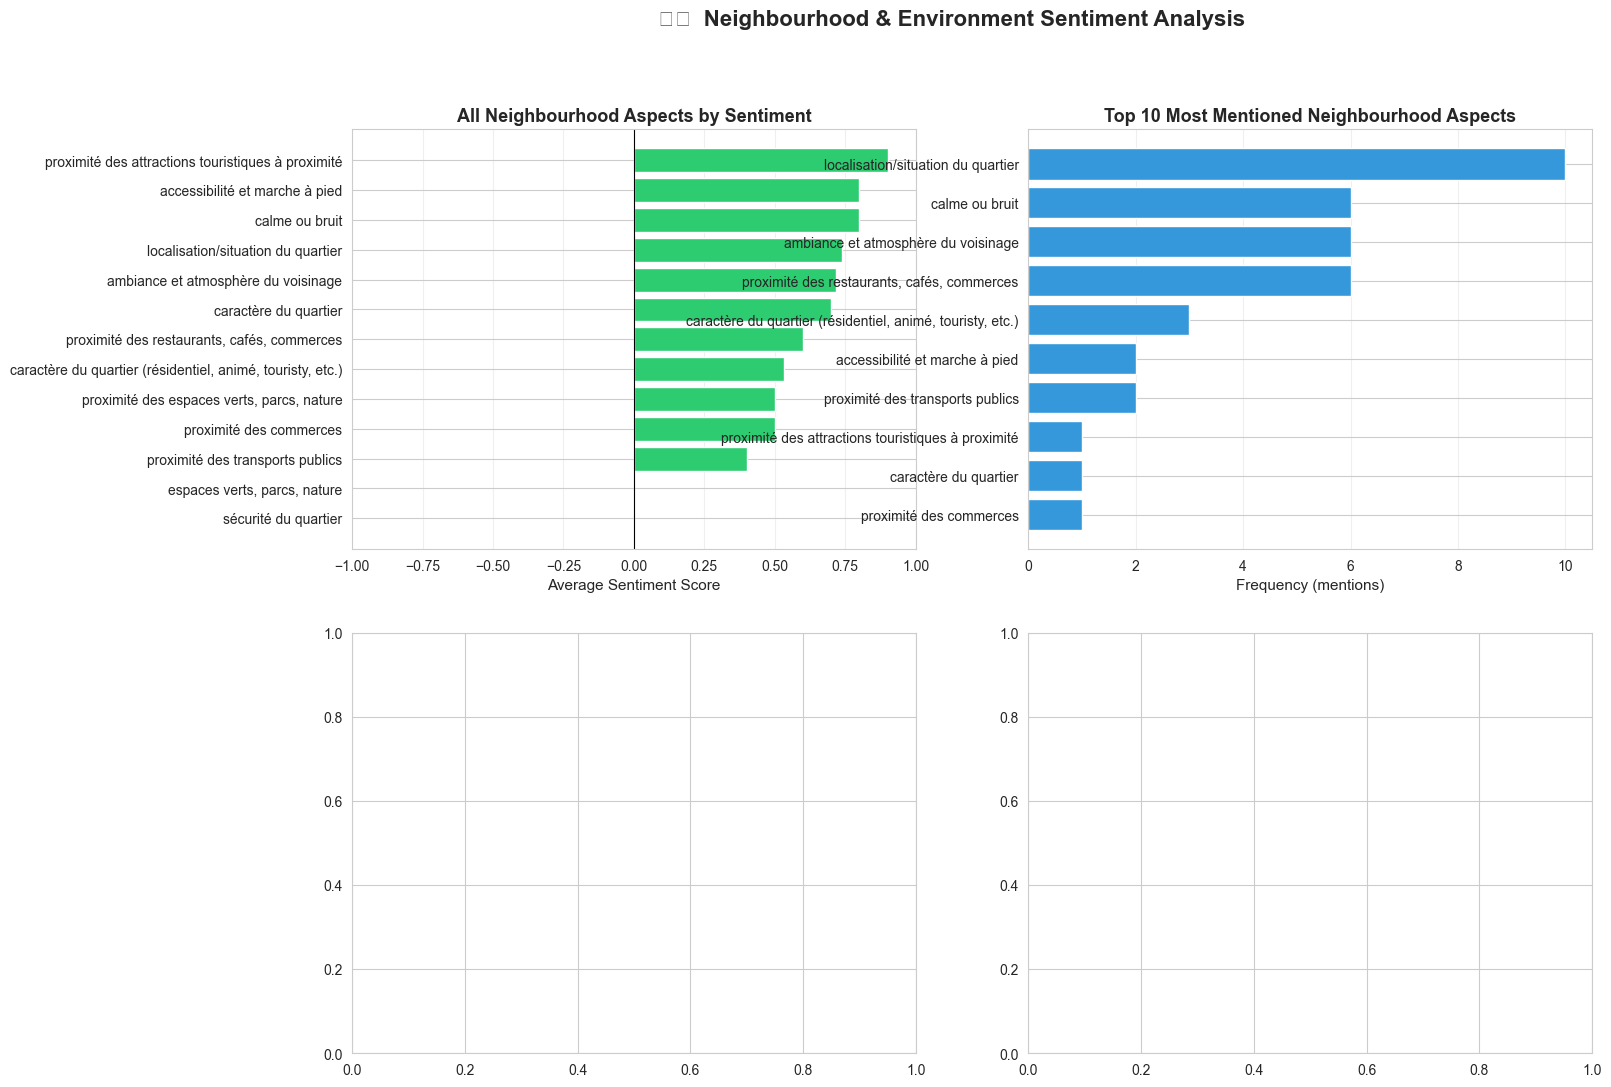

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

if not aspect_stats_df.empty and len(all_aspects_data) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('🏘️  Neighbourhood & Environment Sentiment Analysis', fontsize=16, fontweight='bold')

    # 1. All neighbourhood aspects with sentiment
    all_aspects = aspect_stats_df.sort_values('avg_sentiment')
    colors = ['#2ecc71' if x > 0.3 else '#e74c3c' if x < -0.3 else '#95a5a6' for x in all_aspects['avg_sentiment']]
    axes[0, 0].barh(all_aspects['aspect'], all_aspects['avg_sentiment'], color=colors)
    axes[0, 0].set_xlabel('Average Sentiment Score', fontsize=11)
    axes[0, 0].set_title('All Neighbourhood Aspects by Sentiment', fontsize=13, fontweight='bold')
    axes[0, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[0, 0].set_xlim(-1, 1)
    axes[0, 0].grid(True, alpha=0.3, axis='x')

    # 2. Frequency of neighbourhood aspects
    top_freq = aspect_stats_df.nlargest(10, 'count')
    axes[0, 1].barh(top_freq['aspect'], top_freq['count'], color='#3498db')
    axes[0, 1].set_xlabel('Frequency (mentions)', fontsize=11)
    axes[0, 1].set_title('Top 10 Most Mentioned Neighbourhood Aspects', fontsize=13, fontweight='bold')
    axes[0, 1].invert_yaxis()
    axes[0, 1].grid(True, alpha=0.3, axis='x')

    # 3. Sentiment distribution
    axes[1, 0].hist(all_sentiments, bins=20, color='#9b59b6', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Sentiment Score', fontsize=11)
    axes[1, 0].set_ylabel('Frequency', fontsize=11)
    axes[1, 0].set_title('Distribution of Neighbourhood Sentiments', fontsize=13, fontweight='bold')
    mean_sent = np.mean(all_sentiments)
    axes[1, 0].axvline(x=mean_sent, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_sent:.2f}')
    axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # 4. Frequency vs Sentiment
    scatter = axes[1, 1].scatter(aspect_stats_df['count'], aspect_stats_df['avg_sentiment'], 
                                 s=400, alpha=0.6, c=aspect_stats_df['avg_sentiment'], 
                                 cmap='RdYlGn', vmin=-1, vmax=1)
    axes[1, 1].set_xlabel('Frequency', fontsize=11)
    axes[1, 1].set_ylabel('Average Sentiment', fontsize=11)
    axes[1, 1].set_title('Neighbourhood Aspects: Frequency vs Sentiment', fontsize=13, fontweight='bold')
    axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    axes[1, 1].set_ylim(-1, 1)
    axes[1, 1].grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=axes[1, 1])
    cbar.set_label('Sentiment', fontsize=10)

    plt.tight_layout()
    plt.show()
    print("\n✓ Visualizations completed!")

else:
    print("\n⚠️  Cannot create visualizations - no neighbourhood data.")

## 9. Export Results

In [ ]:
# Format for CSV export
def format_neighbourhood_aspects(aspects_list):
    if not aspects_list:
        return ''
    formatted = []
    for item in aspects_list:
        aspect = item.get('aspect', 'N/A')
        sentiment = item.get('sentiment', 0)
        try:
            sentiment = float(sentiment)
            formatted.append(f"{aspect} ({sentiment:.2f})")
        except (ValueError, TypeError):
            formatted.append(f"{aspect} (N/A)")
    return ' | '.join(formatted) if formatted else ''

reviews_df['neighbourhood_aspects_string'] = reviews_df['neighbourhood_aspects'].apply(format_neighbourhood_aspects)

# Create output dataframe
output_df = reviews_df[['comments', 'neighbourhood_aspects_string', 'neighbourhood_count']].copy()
output_df.columns = ['Review', 'Neighbourhood_Aspects_and_Sentiments', 'Aspect_Count']

# Save results
output_filename = 'neighbourhood_analysis_results.csv'
output_df.to_csv(output_filename, index=False, encoding='utf-8')

print(f"✓ Results saved to: {output_filename}")
print(f"  Total records: {len(output_df)}")
print(f"  Reviews with neighbourhood aspects: {(output_df['Aspect_Count'] > 0).sum()}")
print(f"  Reviews without: {(output_df['Aspect_Count'] == 0).sum()}")

# Save statistics
if not aspect_stats_df.empty:
    aspect_stats_df.to_csv('neighbourhood_analysis_statistics.csv', index=False, encoding='utf-8')
    print(f"✓ Statistics saved to: neighbourhood_analysis_statistics.csv")
    print(f"  Unique neighbourhood aspects: {len(aspect_stats_df)}")

print(f"\n📋 Preview of results (first 8 reviews):")
print(output_df.head(8).to_string())